## 1. Data Loading & Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

In [3]:
# Data Understanding
matches.shape
deliveries.shape

(260920, 17)

In [4]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [5]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
# Data Quality assessment
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [7]:
matches.duplicated().sum()

np.int64(0)

In [8]:
deliveries.duplicated().sum()

np.int64(0)

In [9]:
# unique wwinners
matches['winner'].unique()

<StringArray>
[      'Kolkata Knight Riders',         'Chennai Super Kings',
            'Delhi Daredevils', 'Royal Challengers Bangalore',
            'Rajasthan Royals',             'Kings XI Punjab',
             'Deccan Chargers',              'Mumbai Indians',
               'Pune Warriors',        'Kochi Tuskers Kerala',
                           nan,         'Sunrisers Hyderabad',
     'Rising Pune Supergiants',               'Gujarat Lions',
      'Rising Pune Supergiant',              'Delhi Capitals',
                'Punjab Kings',              'Gujarat Titans',
        'Lucknow Super Giants', 'Royal Challengers Bengaluru']
Length: 20, dtype: str

In [10]:
# matches with no reslut
matches[matches['winner'].isna()][['season', 'team1', 'team2', 'result']]

,season,team1,team2,result
241,2011,Delhi Daredevils,Pune Warriors,no result
485,2015,Royal Challengers Bangalore,Rajasthan Royals,no result
511,2015,Royal Challengers Bangalore,Delhi Daredevils,no result
744,2019,Royal Challengers Bangalore,Rajasthan Royals,no result
994,2023,Lucknow Super Giants,Chennai Super Kings,no result


In [11]:
matches[matches['winner'].isna()]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NaN,NJ Llong,UV Gandhe
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


In [12]:
matches['result'].value_counts()

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64

## 2. Data Cleaning

In [13]:
# cleaning the team names
team_mapping={
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru',
    'Royal Challengers Bangaluru': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant':'Rising Pune Supergiants',
}

In [14]:
matches['team1'].unique()

<StringArray>
['Royal Challengers Bangalore',             'Kings XI Punjab',
            'Delhi Daredevils',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str

In [15]:
matches['winner'].value_counts()

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

In [16]:
# replacing the team names in matches and deliveries dataset
for col in['team1','team2','toss_winner','winner']:
    matches[col]=matches[col].replace(team_mapping)

In [17]:
for col in['batting_team','bowling_team']:
    deliveries[col]=deliveries[col].replace(team_mapping)

In [18]:
matches['team1'].unique()

<StringArray>
['Royal Challengers Bengaluru',                'Punjab Kings',
              'Delhi Capitals',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',        'Lucknow Super Giants',
              'Gujarat Titans']
Length: 15, dtype: str

In [19]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


## 3. Toss Analysis

In [20]:
# createing new column to check if toss winner is match winner
matches['toss_match_winner']=matches['toss_winner']==matches['winner']

In [21]:
matches[['toss_winner','winner','toss_match_winner']].head(10)

,toss_winner,winner,toss_match_winner
0,Royal Challengers Bengaluru,Kolkata Knight Riders,False
1,Chennai Super Kings,Chennai Super Kings,True
2,Rajasthan Royals,Delhi Capitals,False
3,Mumbai Indians,Royal Challengers Bengaluru,False
4,Deccan Chargers,Kolkata Knight Riders,False
5,Punjab Kings,Rajasthan Royals,False
6,Deccan Chargers,Delhi Capitals,False
7,Mumbai Indians,Chennai Super Kings,False
8,Rajasthan Royals,Rajasthan Royals,True
9,Mumbai Indians,Punjab Kings,False


In [22]:
# matches actually having a winner notna()-checking does this match have winner?
matches['winner'].notna().sum()

np.int64(1090)

In [23]:
# toss result excluding matches with no result
matches[matches['winner'].notna()]['toss_match_winner'].value_counts()

toss_match_winner
True     554
False    536
Name: count, dtype: int64

In [24]:
# toss result excluding matches with no result in percentage
# Among 1,090 IPL matches that produced a winner, the team winning the toss also won the match in 50.83% of matches, 
# while losing the match in 49.17%.
matches[matches['winner'].notna()]['toss_match_winner'].value_counts(normalize=True) * 100

toss_match_winner
True     50.825688
False    49.174312
Name: proportion, dtype: float64

In [25]:
matches['toss_decision'].value_counts()

toss_decision
field    704
bat      391
Name: count, dtype: int64

In [26]:
matches.groupby('team1')['toss_match_winner'].value_counts()

team1                        toss_match_winner
Chennai Super Kings          True                 67
                             False                61
Deccan Chargers              False                23
                             True                 16
Delhi Capitals               True                 64
                             False                62
Gujarat Lions                True                 10
                             False                 6
Gujarat Titans               False                11
                             True                 10
Kochi Tuskers Kerala         True                  4
                             False                 3
Kolkata Knight Riders        True                 70
                             False                51
Lucknow Super Giants         False                15
                             True                  8
Mumbai Indians               True                 65
                             False                58

In [27]:
# When teams won the toss, was choosing bat or field more likely to result in winning the match?
matches.groupby("toss_decision")["toss_match_winner"].value_counts() 

toss_decision  toss_match_winner
bat            False                214
               True                 177
field          True                 377
               False                327
Name: count, dtype: int64

In [28]:
# Among matches with a winner, how successful was the toss winner when they chose to bat versus when they chose to field?
matches[matches['winner'].notna()].groupby('toss_decision')['toss_match_winner'].value_counts(normalize=True) * 100

toss_decision  toss_match_winner
bat            False                54.615385
               True                 45.384615
field          True                 53.857143
               False                46.142857
Name: proportion, dtype: float64

## 4. Team Performance

In [29]:
# winning percentage of each team from the overall dataset
matches['winner'].value_counts(normalize=True)*100

winner
Mumbai Indians                 13.211009
Chennai Super Kings            12.660550
Kolkata Knight Riders          12.018349
Royal Challengers Bengaluru    11.284404
Delhi Capitals                 10.550459
Rajasthan Royals               10.275229
Punjab Kings                   10.275229
Sunrisers Hyderabad             8.073394
Deccan Chargers                 2.660550
Gujarat Titans                  2.568807
Lucknow Super Giants            2.201835
Rising Pune Supergiants         1.376147
Gujarat Lions                   1.192661
Pune Warriors                   1.100917
Kochi Tuskers Kerala            0.550459
Name: proportion, dtype: float64

In [30]:
team1_counts = matches['team1'].value_counts()
team2_counts = matches['team2'].value_counts()

matches_played = team1_counts + team2_counts
print(matches_played)

team1
Chennai Super Kings            238
Deccan Chargers                 75
Delhi Capitals                 252
Gujarat Lions                   30
Gujarat Titans                  45
Kochi Tuskers Kerala            14
Kolkata Knight Riders          251
Lucknow Super Giants            44
Mumbai Indians                 261
Pune Warriors                   46
Punjab Kings                   246
Rajasthan Royals               221
Rising Pune Supergiants         30
Royal Challengers Bengaluru    255
Sunrisers Hyderabad            182
Name: count, dtype: int64


In [31]:
wins=matches['winner'].value_counts()
print(wins)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64


In [32]:
# winning percentage of each team for the matches they have played
win_percentage=(wins/matches_played)*100
win_percentage.sort_values(ascending=False)
win_percentage

winner
Chennai Super Kings            57.983193
Deccan Chargers                38.666667
Delhi Capitals                 45.634921
Gujarat Lions                  43.333333
Gujarat Titans                 62.222222
Kochi Tuskers Kerala           42.857143
Kolkata Knight Riders          52.191235
Lucknow Super Giants           54.545455
Mumbai Indians                 55.172414
Pune Warriors                  26.086957
Punjab Kings                   45.528455
Rajasthan Royals               50.678733
Rising Pune Supergiants        50.000000
Royal Challengers Bengaluru    48.235294
Sunrisers Hyderabad            48.351648
Name: count, dtype: float64

In [33]:
# matches win per season
matches.groupby(['season','winner']).size()

season   winner                     
2007/08  Chennai Super Kings            9
         Deccan Chargers                2
         Delhi Capitals                 7
         Kolkata Knight Riders          6
         Mumbai Indians                 7
                                       ..
2024     Mumbai Indians                 4
         Punjab Kings                   5
         Rajasthan Royals               9
         Royal Challengers Bengaluru    7
         Sunrisers Hyderabad            9
Length: 146, dtype: int64

In [34]:
# Count the number of wins for each team in each season
season_wins = matches.groupby(['season', 'winner']).size().reset_index(name='wins')
season_wins.head(10)

,season,winner,wins
0,2007/08,Chennai Super Kings,9
1,2007/08,Deccan Chargers,2
2,2007/08,Delhi Capitals,7
3,2007/08,Kolkata Knight Riders,6
4,2007/08,Mumbai Indians,7
5,2007/08,Punjab Kings,10
6,2007/08,Rajasthan Royals,13
7,2007/08,Royal Challengers Bengaluru,4
8,2009,Chennai Super Kings,8
9,2009,Deccan Chargers,9


In [35]:
# Find the team with the highest number of wins in each season
season_wins.loc[season_wins.groupby('season')['wins'].idxmax()]

,season,winner,wins
6,2007/08,Rajasthan Royals,13
10,2009,Delhi Capitals,10
20,2009/10,Mumbai Indians,11
24,2011,Chennai Super Kings,11
37,2012,Kolkata Knight Riders,12
46,2013,Mumbai Indians,13
56,2014,Punjab Kings,12
60,2015,Chennai Super Kings,10
75,2016,Sunrisers Hyderabad,11
79,2017,Mumbai Indians,12


In [36]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')

## 5. Batting Analysis

In [37]:
# top run scorer
top_run_scorer=deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False)
top_run_scorer.head(10)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

In [38]:
deliveries=deliveries.merge(
matches[['id','season']],
left_on='match_id',
right_on='id',
how='left' 
)                           

In [39]:
best_season_batter=deliveries.groupby(['season','batter'])['batsman_runs'].sum().reset_index(name='Most runs')
best_season_batter

,season,batter,Most runs
0,2007/08,A Chopra,42
1,2007/08,A Kumble,13
2,2007/08,A Mishra,37
3,2007/08,A Mukund,0
4,2007/08,A Nehra,3
...,...,...,...
2612,2024,WG Jacks,230
2613,2024,WP Saha,136
2614,2024,Washington Sundar,0
2615,2024,YBK Jaiswal,435


In [40]:
best_season_batter.groupby('season')['Most runs'].idxmax()

season
2007/08     115
2009        229
2009/10     446
2011        502
2012        684
2013        910
2014       1088
2015       1148
2016       1383
2017       1422
2018       1594
2019       1694
2020/21    1866
2021       2051
2022       2144
2023       2423
2024       2606
Name: Most runs, dtype: int64

In [41]:
# highest run scorer from each season
season_batting=best_season_batter.loc[best_season_batter.groupby('season')['Most runs'].idxmax()]
season_batting

,season,batter,Most runs
115,2007/08,SE Marsh,616
229,2009,ML Hayden,572
446,2009/10,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641


In [42]:
# batter with runs and balls faced
batting_stats=deliveries.groupby('batter').agg(
runs=('batsman_runs','sum'),
balls=('batter','count')
).reset_index()
batting_stats

,batter,runs,balls
0,A Ashish Reddy,280,196
1,A Badoni,634,505
2,A Chandila,4,7
3,A Chopra,53,75
4,A Choudhary,25,20
...,...,...,...
668,Yashpal Singh,47,67
669,Younis Khan,3,7
670,Yudhvir Singh,22,16
671,Yuvraj Singh,2754,2207


In [43]:
# strike rate calculation
batting_stats['strike_rate'] = (
    batting_stats['runs'] / batting_stats['balls']
) * 100
batting_stats.head(10)

,batter,runs,balls,strike_rate
0,A Ashish Reddy,280,196,142.857143
1,A Badoni,634,505,125.544554
2,A Chandila,4,7,57.142857
3,A Chopra,53,75,70.666667
4,A Choudhary,25,20,125.000000
5,A Dananjaya,4,5,80.000000
6,A Flintoff,62,57,108.771930
7,A Kamboj,2,2,100.000000
8,A Kumble,35,49,71.428571
9,A Manohar,231,181,127.624309


In [44]:
# batsman strike rate who had minimum 100 balls
qualified_batters = batting_stats[batting_stats['balls'] >= 100]
qualified_batters

,batter,runs,balls,strike_rate
0,A Ashish Reddy,280,196,142.857143
1,A Badoni,634,505,125.544554
9,A Manohar,231,181,127.624309
10,A Mishra,381,440,86.590909
15,A Raghuvanshi,163,109,149.541284
...,...,...,...,...
662,YBK Jaiswal,1607,1095,146.757991
663,YK Pathan,3222,2334,138.046272
666,YV Takawale,192,183,104.918033
671,Yuvraj Singh,2754,2207,124.784776


In [45]:
# calculating highest strike rate 
qualified_batters.sort_values('strike_rate',ascending=False).head(10)



,batter,runs,balls,strike_rate
234,J Fraser-McGurk,330,150,220.000000
652,WG Jacks,230,133,172.932331
433,PD Salt,653,385,169.610390
606,T Stubbs,405,239,169.456067
617,TM Head,772,458,168.558952
39,AD Russell,2488,1515,164.224422
105,BCJ Cutting,238,146,163.013699
208,H Klaasen,993,613,161.990212
503,Ramandeep Singh,170,106,160.377358
85,Ashutosh Sharma,189,118,160.169492


## 6. Bowling Analysis

In [46]:
# Highest wicket taker 
wickets = deliveries.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False)

wickets.head(10)

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: is_wicket, dtype: int64

In [47]:
# dismissal type
deliveries[deliveries['is_wicket'] == 1]['dismissal_kind'].value_counts()

dismissal_kind
caught                   8063
bowled                   2212
run out                  1114
lbw                       800
caught and bowled         367
stumped                   358
retired hurt               15
hit wicket                 15
obstructing the field       3
retired out                 3
Name: count, dtype: int64

In [48]:
# Filter out non-bowler dismissals
bowler_wickets=deliveries[~deliveries['dismissal_kind'].isin([
    'run out',
    'retired out',
    'obstructing the field',
    'retired hurt'
])
]
bowler_wickets

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,season
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,335982,2007/08
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,335982,2007/08
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260915,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,AK Markram,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN,1426312,2024
260916,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,AK Markram,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN,1426312,2024
260917,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,Shahbaz Ahmed,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN,1426312,2024
260918,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,Shahbaz Ahmed,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN,1426312,2024


In [49]:
# wicket count after filtering and than group by
wickets = bowler_wickets.groupby('bowler')['is_wicket'].sum()
wickets=wickets.sort_values(ascending=False)

wickets.head(10)

bowler
YS Chahal     205
PP Chawla     192
DJ Bravo      183
B Kumar       181
SP Narine     180
R Ashwin      180
A Mishra      174
SL Malinga    170
JJ Bumrah     168
RA Jadeja     160
Name: is_wicket, dtype: int64

In [50]:
season_wickets=bowler_wickets.groupby(['season','bowler'])['is_wicket'].sum().reset_index(name='Most wickets')
season_wickets.head()

,season,bowler,Most wickets
0,2007/08,A Kumble,7
1,2007/08,A Mishra,11
2,2007/08,A Nehra,12
3,2007/08,A Nel,1
4,2007/08,A Symonds,0


In [51]:
# highest wicket taker in each season
best_season_bowler=season_wickets.loc[season_wickets.groupby('season')['Most wickets'].idxmax()]
best_season_bowler

,season,bowler,Most wickets
84,2007/08,Sohail Tanvir,22
174,2009,RP Singh,23
284,2009/10,PP Ojha,21
447,2011,SL Malinga,28
537,2012,M Morkel,25
629,2013,DJ Bravo,32
779,2014,MM Sharma,23
847,2015,DJ Bravo,26
938,2016,B Kumar,23
1048,2017,B Kumar,26


In [52]:
# runs conceded by each bowler
bowling_runs = deliveries.groupby('bowler')['total_runs'].sum()
bowling_runs

bowler
A Ashish Reddy     400
A Badoni            37
A Chandila         245
A Choudhary        144
A Dananjaya         47
                  ... 
Yash Dayal         933
Yash Thakur        702
Yudhvir Singh      125
Yuvraj Singh      1091
Z Khan            2860
Name: total_runs, Length: 530, dtype: int64

In [53]:
# extra types
deliveries['extras_type'].value_counts(dropna=False)

extras_type
NaN        246795
wides        8380
legbyes      4001
noballs      1069
byes          673
penalty         2
Name: count, dtype: int64

In [54]:
# runs conceeded by bowler excluding byes legbyes and penalty 
bowling_runs = deliveries[
    ~deliveries['extras_type'].isin(['byes', 'legbyes', 'penalty'])
].groupby('bowler')['total_runs'].sum()
bowling_runs

bowler
A Ashish Reddy     396
A Badoni            36
A Chandila         242
A Choudhary        144
A Dananjaya         47
                  ... 
Yash Dayal         919
Yash Thakur        691
Yudhvir Singh      122
Yuvraj Singh      1077
Z Khan            2782
Name: total_runs, Length: 530, dtype: int64

In [55]:
# counting legal deliveries 
legal_balls=deliveries[~deliveries['extras_type'].isin(['wides','noballs'])].groupby('bowler').size()
legal_balls

bowler
A Ashish Reddy     262
A Badoni            25
A Chandila         234
A Choudhary        101
A Dananjaya         24
                  ... 
Yash Dayal         578
Yash Thakur        404
Yudhvir Singh       72
Yuvraj Singh       869
Z Khan            2200
Length: 530, dtype: int64

In [56]:
# economy calculation
economy=(bowling_runs/legal_balls)*6
economy

bowler
A Ashish Reddy     9.068702
A Badoni           8.640000
A Chandila         6.205128
A Choudhary        8.554455
A Dananjaya       11.750000
                    ...    
Yash Dayal         9.539792
Yash Thakur       10.262376
Yudhvir Singh     10.166667
Yuvraj Singh       7.436133
Z Khan             7.587273
Length: 530, dtype: float64

In [57]:
bowling_stats = pd.DataFrame({
    'runs_conceded': bowling_runs,
    'legal_balls': legal_balls
})

bowling_stats['economy_rate'] = (
    bowling_stats['runs_conceded'] /
    bowling_stats['legal_balls']
) * 6
bowling_stats

,runs_conceded,legal_balls,economy_rate
bowler,,,
A Ashish Reddy,396,262,9.068702
A Badoni,36,25,8.640000
A Chandila,242,234,6.205128
A Choudhary,144,101,8.554455
A Dananjaya,47,24,11.750000
...,...,...,...
Yash Dayal,919,578,9.539792
Yash Thakur,691,404,10.262376
Yudhvir Singh,122,72,10.166667


In [58]:
qualified_bowlers=bowling_stats[bowling_stats['legal_balls']>=300]
qualified_bowlers

,runs_conceded,legal_balls,economy_rate
bowler,,,
A Kumble,1058,965,6.578238
A Mishra,4145,3371,7.377633
A Nehra,2495,1908,7.845912
A Nortje,1574,1054,8.960152
A Singh,620,473,7.864693
...,...,...,...
YS Chahal,4602,3521,7.842090
Yash Dayal,919,578,9.539792
Yash Thakur,691,404,10.262376


In [59]:
# Top 10 plaayers with best economy rate
qualified_bowlers.sort_values('economy_rate',ascending=True).head(10)


,runs_conceded,legal_balls,economy_rate
bowler,,,
A Kumble,1058,965,6.578238
GD McGrath,357,324,6.611111
M Muralitharan,1706,1528,6.698953
SP Narine,4582,4081,6.736584
RE van der Merwe,498,443,6.744921
DL Vettori,879,777,6.787645
Rashid Khan,3267,2872,6.825209
J Yadav,445,390,6.846154
J Botha,800,694,6.916427


In [60]:
# bowling strike rate
bowling_stats['strike_rate'] = (
    bowling_stats['legal_balls'] / wickets
)

In [61]:
bowling_stats['wickets'] = wickets

In [62]:
bowling_stats.head()

,runs_conceded,legal_balls,economy_rate,strike_rate,wickets
bowler,,,,,
A Ashish Reddy,396,262,9.068702,14.555556,18
A Badoni,36,25,8.640000,12.500000,2
A Chandila,242,234,6.205128,21.272727,11
A Choudhary,144,101,8.554455,20.200000,5
A Dananjaya,47,24,11.750000,inf,0


In [63]:
qualified_bowlers_sr = bowling_stats[
    bowling_stats['wickets'] >= 50
]
qualified_bowlers_sr

,runs_conceded,legal_balls,economy_rate,strike_rate,wickets
bowler,,,,,
A Mishra,4145,3371,7.377633,19.373563,174
A Nehra,2495,1908,7.845912,18.000000,106
A Nortje,1574,1054,8.960152,17.566667,60
AB Dinda,2073,1516,8.204485,21.971014,69
AD Russell,2646,1697,9.355333,14.756522,115
...,...,...,...,...,...
T Natarajan,1969,1337,8.836200,19.955224,67
TA Boult,3245,2341,8.316959,19.347107,121
UT Yadav,4331,3057,8.500491,21.229167,144


In [64]:
# bowling strike rate
qualified_bowlers_sr['strike_rate'] = (
    qualified_bowlers_sr['legal_balls'] /
    qualified_bowlers_sr['wickets']
)

In [65]:
qualified_bowlers_sr.sort_values(
    'strike_rate',
    ascending=True
).head(10)

,runs_conceded,legal_balls,economy_rate,strike_rate,wickets
bowler,,,,,
AD Russell,2646,1697,9.355333,14.756522,115
K Rabada,2577,1829,8.453800,15.241667,120
HV Patel,3148,2162,8.736355,16.014815,135
Imran Tahir,1703,1316,7.764438,16.048780,82
MA Starc,1137,831,8.209386,16.294118,51
SL Malinga,3364,2828,7.137199,16.635294,170
DJ Bravo,4360,3120,8.384615,17.049180,183
MM Sharma,3256,2253,8.671105,17.068182,132
YS Chahal,4602,3521,7.842090,17.175610,205


In [66]:
# best match figure
match_bowling_stats = bowler_wickets[
    ~bowler_wickets['extras_type'].isin(['byes', 'legbyes', 'penalty'])
].groupby(
    ['match_id', 'bowler']
).agg(
    wickets=('is_wicket', 'sum'),
    runs_conceded=('total_runs', 'sum')
).reset_index()

In [67]:
match_bowling_stats.sort_values(
    ['wickets', 'runs_conceded'],
    ascending=[False, True]
).head(10)

,match_id,bowler,wickets,runs_conceded
8498,1178394,AS Joseph,6,12
290,336005,Sohail Tanvir,6,14
6608,980979,A Zampa,6,19
695,392182,A Kumble,5,5
12085,1370351,Akash Madhwal,5,5
11008,1304102,JJ Bumrah,5,10
12104,1370352,MM Sharma,5,10
2491,501229,I Sharma,5,12
2167,501201,SL Malinga,5,13
7856,1136585,AS Rajpoot,5,14


## 7. Venue & Match Margin Analysis

In [68]:
# venue analysis
venue_counts = matches['venue'].value_counts()

venue_counts.head(10)

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64

In [69]:
venue_mapping={
"Wankhede Stadium":"Wankhede Stadium, Mumbai"    
}

In [70]:
matches['venue']=matches['venue'].replace(venue_mapping)

In [71]:
# adding venue to deliveries data set
deliveries = deliveries.merge(
    matches[['id', 'venue']],
    left_on='match_id',
    right_on='id',
    how='left'
)

In [72]:
venue_team_runs = deliveries.groupby(
    ['venue', 'match_id', 'batting_team']
)['total_runs'].sum().reset_index(name='runs')
venue_team_runs

,venue,match_id,batting_team,runs
0,Arun Jaitley Stadium,1136582,Delhi Capitals,139
1,Arun Jaitley Stadium,1136582,Punjab Kings,143
2,Arun Jaitley Stadium,1136586,Delhi Capitals,219
3,Arun Jaitley Stadium,1136586,Kolkata Knight Riders,164
4,Arun Jaitley Stadium,1136592,Delhi Capitals,196
...,...,...,...,...
2182,"Zayed Cricket Stadium, Abu Dhabi",1254097,Rajasthan Royals,121
2183,"Zayed Cricket Stadium, Abu Dhabi",1254098,Chennai Super Kings,172
2184,"Zayed Cricket Stadium, Abu Dhabi",1254098,Kolkata Knight Riders,171
2185,"Zayed Cricket Stadium, Abu Dhabi",1254099,Mumbai Indians,137


In [73]:
# average run scored at the venue
avg_venue_runs = venue_team_runs.groupby(
    'venue'
)['runs'].mean().sort_values(ascending=False)
avg_venue_runs.head(10)

venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    200.000000
Arun Jaitley Stadium, Delhi                                           190.343750
Eden Gardens, Kolkata                                                 190.156250
M Chinnaswamy Stadium, Bengaluru                                      190.071429
Himachal Pradesh Cricket Association Stadium, Dharamsala              189.375000
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      185.600000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  182.423077
Brabourne Stadium                                                     174.050000
Punjab Cricket Association IS Bindra Stadium                          173.800000
Brabourne Stadium, Mumbai                                             171.294118
Name: runs, dtype: float64

In [74]:
# winning margin
biggest_run_wins = matches[
    matches['result'] == 'runs'
].sort_values(
    'result_margin',
    ascending=False
)
biggest_run_wins[
    ['season', 'team1', 'team2', 'winner', 'result_margin']
].head(10)

,season,team1,team2,winner,result_margin
620,2017,Delhi Capitals,Mumbai Indians,Mumbai Indians,146.0
560,2016,Royal Challengers Bengaluru,Gujarat Lions,Royal Challengers Bengaluru,144.0
0,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,140.0
496,2015,Royal Challengers Bengaluru,Punjab Kings,Royal Challengers Bengaluru,138.0
352,2013,Royal Challengers Bengaluru,Pune Warriors,Royal Challengers Bengaluru,130.0
706,2019,Sunrisers Hyderabad,Royal Challengers Bengaluru,Sunrisers Hyderabad,118.0
1009,2023,Royal Challengers Bengaluru,Rajasthan Royals,Royal Challengers Bengaluru,112.0
236,2011,Punjab Kings,Royal Challengers Bengaluru,Punjab Kings,111.0
1039,2024,Kolkata Knight Riders,Delhi Capitals,Kolkata Knight Riders,106.0
55,2007/08,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,105.0


## 8. Head-to-Head Analysis

In [75]:
# head to head analysis
matches['team_a'] = matches[['team1', 'team2']].min(axis=1)
matches['team_b'] = matches[['team1', 'team2']].max(axis=1)

matches['matchup'] = matches['team_a'] + ' vs ' + matches['team_b']

In [76]:
head_to_head = matches[
    matches['winner'].notna()
].groupby(
    ['matchup', 'winner']
).size().reset_index(name='wins')
head_to_head

,matchup,winner,wins
0,Chennai Super Kings vs Deccan Chargers,Chennai Super Kings,6
1,Chennai Super Kings vs Deccan Chargers,Deccan Chargers,4
2,Chennai Super Kings vs Delhi Capitals,Chennai Super Kings,19
3,Chennai Super Kings vs Delhi Capitals,Delhi Capitals,11
4,Chennai Super Kings vs Gujarat Titans,Chennai Super Kings,3
...,...,...,...
152,Rising Pune Supergiants vs Royal Challengers B...,Royal Challengers Bengaluru,2
153,Rising Pune Supergiants vs Sunrisers Hyderabad,Rising Pune Supergiants,3
154,Rising Pune Supergiants vs Sunrisers Hyderabad,Sunrisers Hyderabad,1
155,Royal Challengers Bengaluru vs Sunrisers Hyder...,Royal Challengers Bengaluru,11


## 1. Visualization and Insights

### Does winning the toss help win the match?

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3756\2336792492.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=matches[matches['winner'].notna()], x='toss_match_winner', palette='pastel')


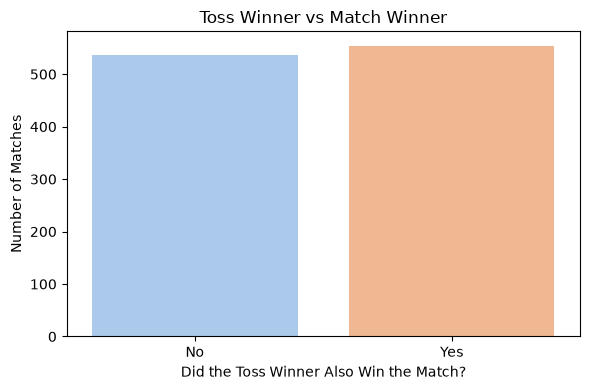

In [77]:
plt.figure(figsize=(6, 4))
sns.countplot(data=matches[matches['winner'].notna()], x='toss_match_winner', palette='pastel')
plt.title('Toss Winner vs Match Winner')
plt.xlabel('Did the Toss Winner Also Win the Match?')
plt.ylabel('Number of Matches')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()

**Insight:** Winning the toss barely matters — the toss winner also won the match in 50.83% of matches, and lost in 49.17%. Essentially a coin flip with no real predictive value.

### Is choosing to bat or field after winning the toss better?

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3756\3562198705.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=toss_decision_success.index, y=toss_decision_success.values, palette='Set2')


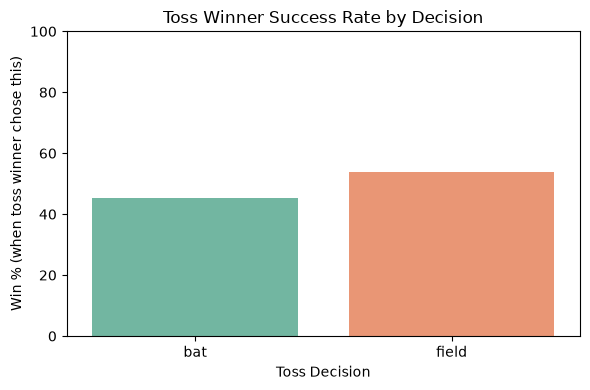

In [78]:
toss_decision_success = (
    matches[matches['winner'].notna()]
    .groupby('toss_decision')['toss_match_winner']
    .mean() * 100
)

plt.figure(figsize=(6, 4))
sns.barplot(x=toss_decision_success.index, y=toss_decision_success.values, palette='Set2')
plt.title('Toss Winner Success Rate by Decision')
plt.xlabel('Toss Decision')
plt.ylabel('Win % (when toss winner chose this)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Insight:** Choosing to field first pays off more often — teams that fielded after winning the toss won 53.86% of the time, versus only 45.38% when they chose to bat first. This matches the well-known IPL trend of chasing being favored.

### Which teams have the best overall win percentage?

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3756\208062370.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_percentage_sorted.values, y=win_percentage_sorted.index, palette='viridis')


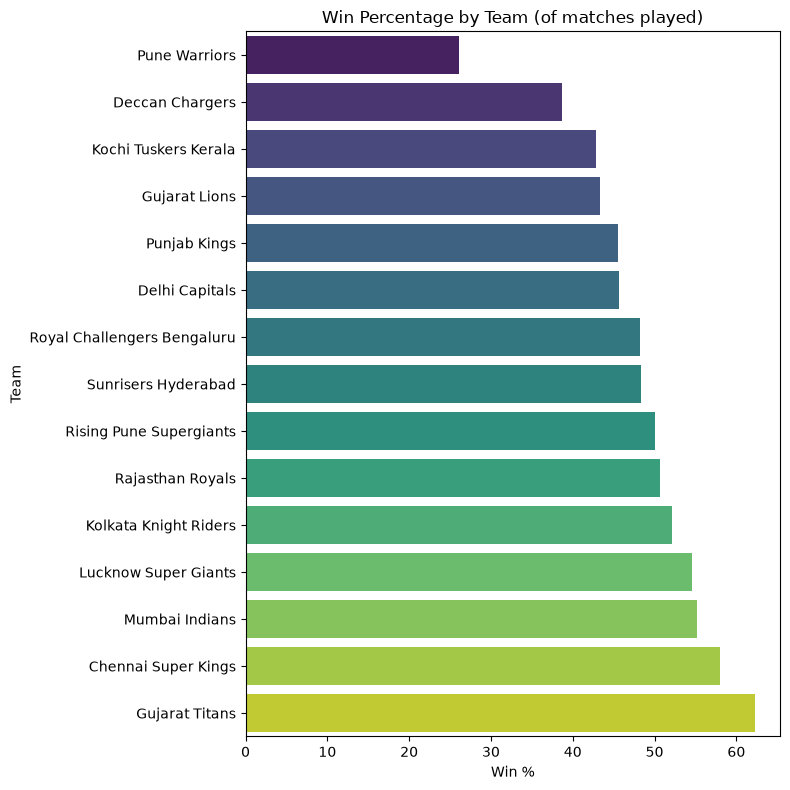

In [79]:
win_percentage_sorted = win_percentage.sort_values(ascending=True)

plt.figure(figsize=(8, 8))
sns.barplot(x=win_percentage_sorted.values, y=win_percentage_sorted.index, palette='viridis')
plt.title('Win Percentage by Team (of matches played)')
plt.xlabel('Win %')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

**Insight:** Gujarat Titans (62.2%) and Chennai Super Kings (57.98%) have the best win percentages of any franchise, with Mumbai Indians (55.17%) and Lucknow Super Giants (54.55%) close behind. At the other end, Pune Warriors (26.09%) and Deccan Chargers (38.67%) are the weakest performers among teams with a meaningful number of matches played.

### How do team wins vary season by season?

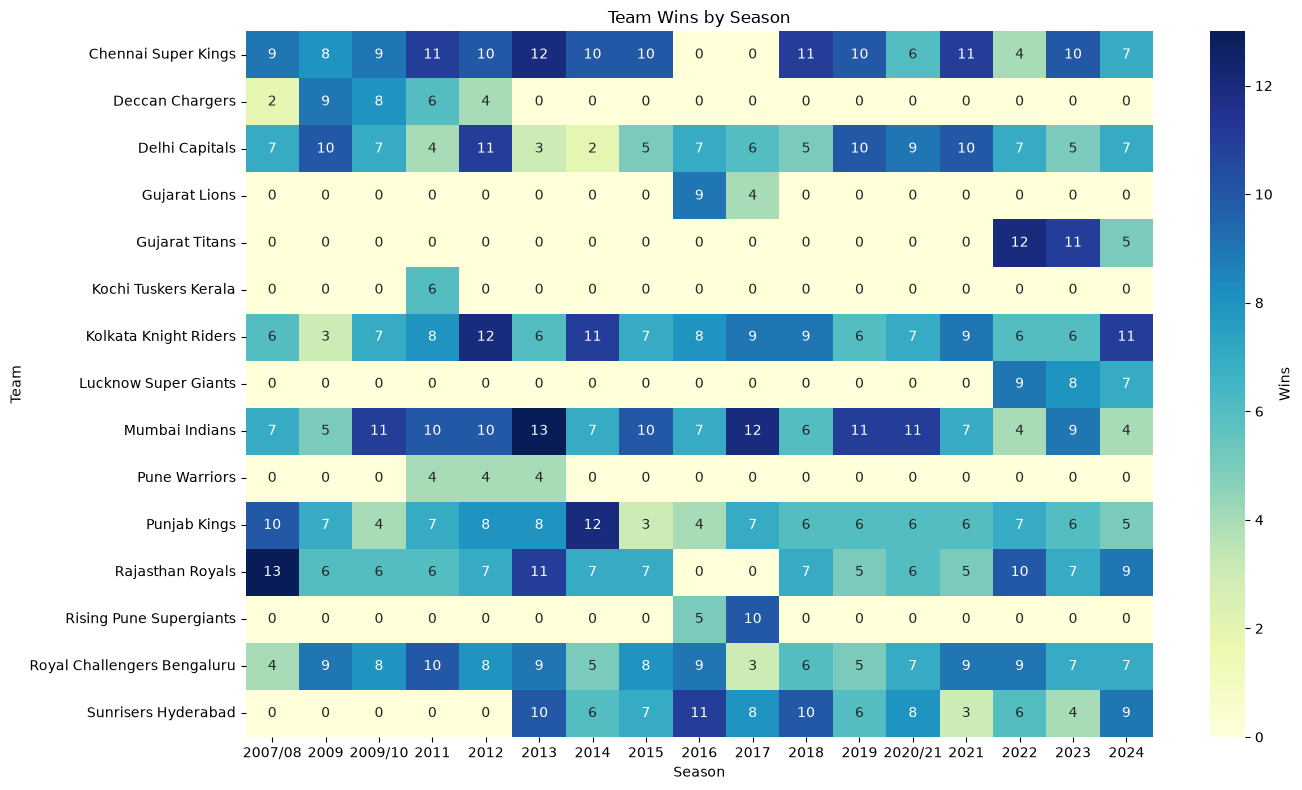

In [80]:
season_team_pivot = matches.groupby(['season', 'winner']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(season_team_pivot.T, cmap='YlGnBu', annot=True, fmt='d', cbar_kws={'label': 'Wins'})
plt.title('Team Wins by Season')
plt.xlabel('Season')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

**Insight:** No team dominates every season — 8 different franchises have topped a season's win count across the 17 seasons played. Mumbai Indians (6 seasons) and Chennai Super Kings (4 seasons) have led most often, but Gujarat Titans, Kolkata Knight Riders, Rajasthan Royals, Delhi Capitals, Punjab Kings, and Sunrisers Hyderabad have each topped at least one season too.

### Who are the all-time top run scorers?

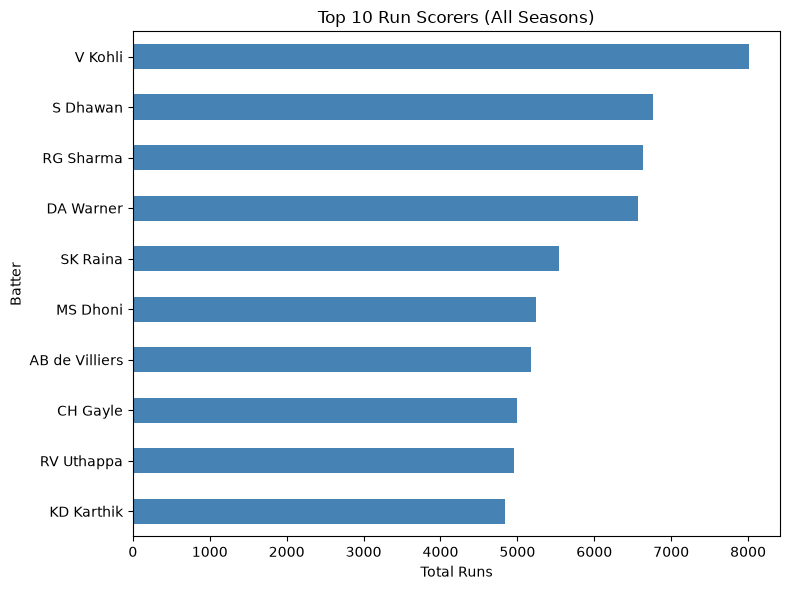

In [81]:
plt.figure(figsize=(8, 6))
top_run_scorer.head(10).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Run Scorers (All Seasons)')
plt.xlabel('Total Runs')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

**Insight:** V Kohli leads all-time run scoring with 8,014 runs, ahead of S Dhawan (6,769), RG Sharma (6,630), and DA Warner (6,567). This list is dominated by batters with long IPL careers, showing that total runs rewards longevity and consistency as much as peak form.

### Who has the best strike rate among established batters?

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3756\1077133137.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_strike_rate, x='strike_rate', y='batter', palette='rocket')


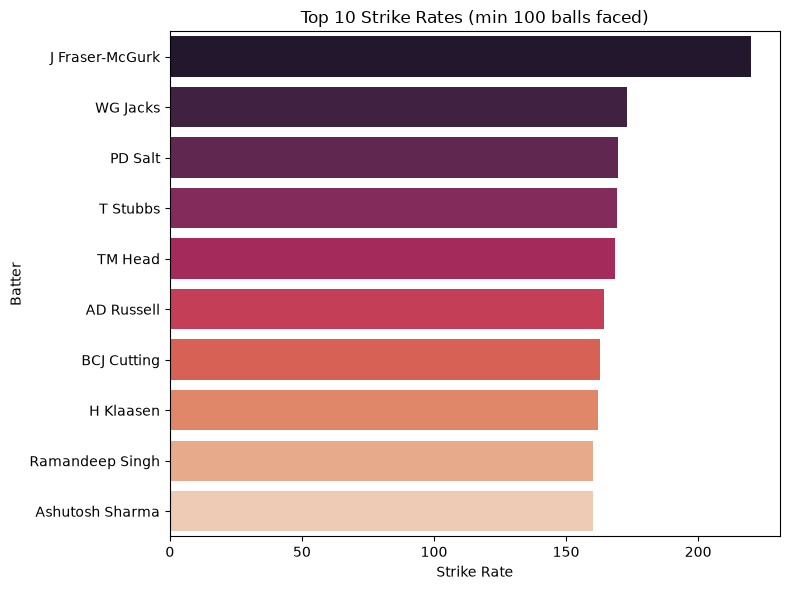

In [82]:
top_strike_rate = qualified_batters.sort_values('strike_rate', ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_strike_rate, x='strike_rate', y='batter', palette='rocket')
plt.title('Top 10 Strike Rates (min 100 balls faced)')
plt.xlabel('Strike Rate')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

**Insight:** The highest strike rates belong to more recent, aggressive batters — J Fraser-McGurk tops the list at 220.0 (on 150 balls), followed by WG Jacks (172.93) and PD Salt (169.61). None of these names overlap with the top run-scorers list, confirming a real split between 'volume' accumulators and explosive, high-strike-rate hitters.

### Who are the top wicket takers?

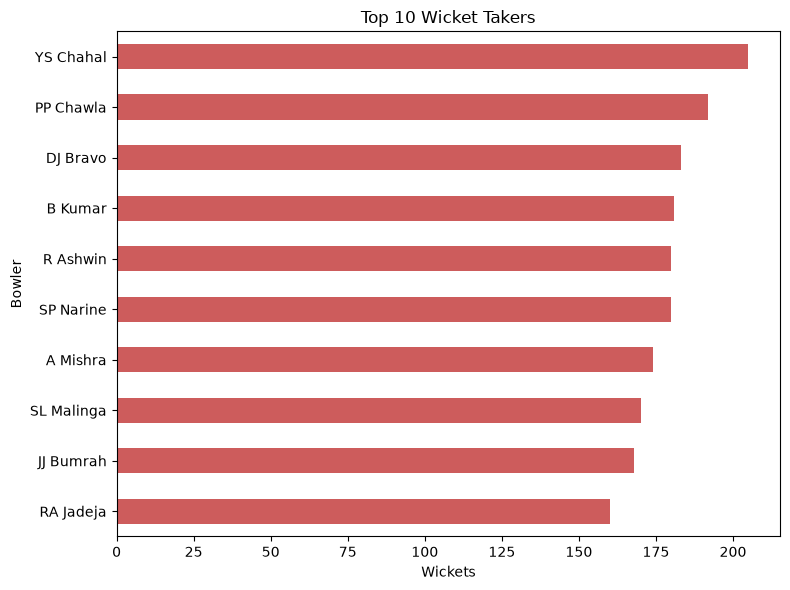

In [83]:
plt.figure(figsize=(8, 6))
wickets.head(10).sort_values().plot(kind='barh', color='indianred')
plt.title('Top 10 Wicket Takers')
plt.xlabel('Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

**Insight:** YS Chahal leads all bowlers with 205 wickets, followed by PP Chawla (192) and DJ Bravo (183). Like batting, this list favors bowlers with long careers in the league rather than a single standout season.

### Who are the most economical bowlers?

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3756\2386832899.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_economy['economy_rate'], y=top_economy.index, palette='crest')


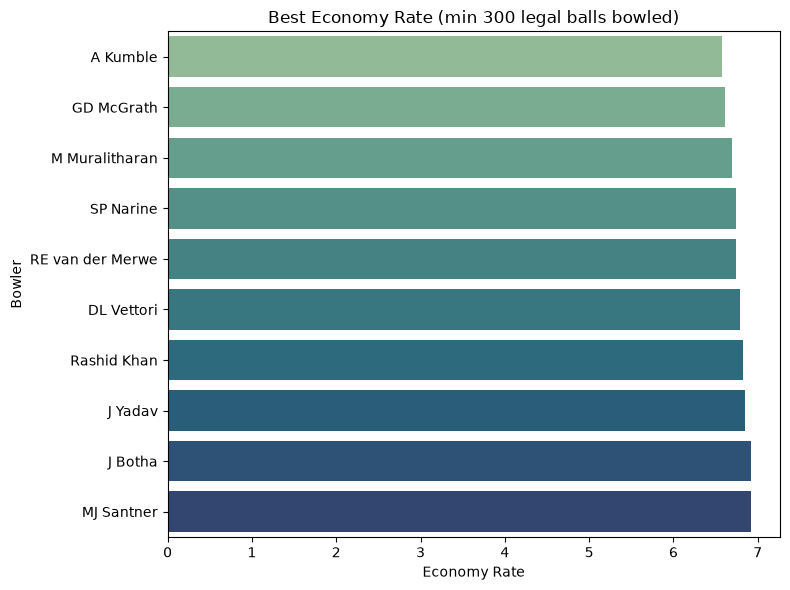

In [84]:
economy_qualified = bowling_stats[bowling_stats['legal_balls'] >= 300]
top_economy = economy_qualified.sort_values('economy_rate').head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_economy['economy_rate'], y=top_economy.index, palette='crest')
plt.title('Best Economy Rate (min 300 legal balls bowled)')
plt.xlabel('Economy Rate')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

**Insight:** A Kumble has the best economy rate among qualified bowlers at 6.58 runs/over, followed by GD McGrath (6.61) and M Muralitharan (6.70). This list is dominated by spinners, confirming that economy rate rewards control and containment — a very different skill from raw wicket-taking, where pacers like Bumrah and Malinga also feature prominently.

### Which venues produce the highest-scoring games?

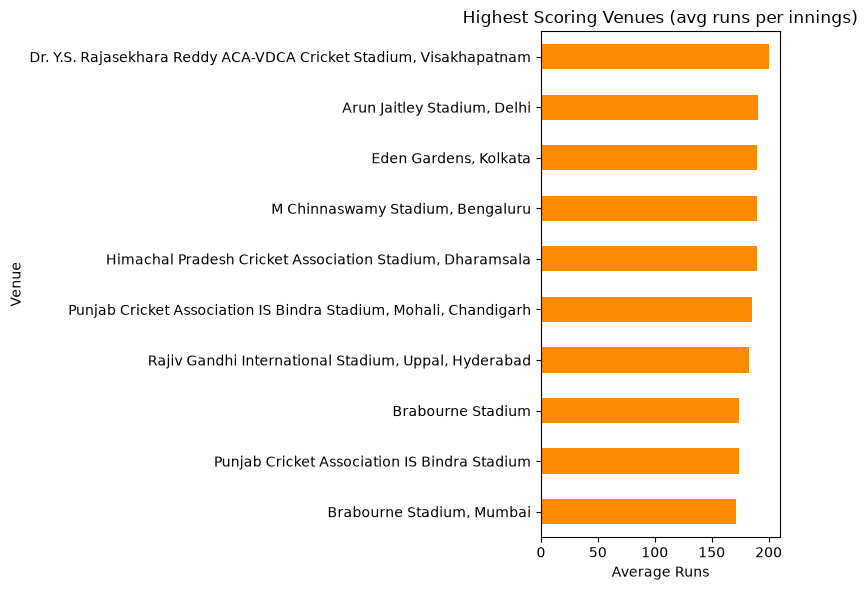

In [85]:
plt.figure(figsize=(8, 6))
avg_venue_runs.head(10).sort_values().plot(kind='barh', color='darkorange')
plt.title('Highest Scoring Venues (avg runs per innings)')
plt.xlabel('Average Runs')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

**Insight:** The Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium in Visakhapatnam has the highest average innings total (200 runs), followed by Arun Jaitley Stadium, Delhi (190.3) and Eden Gardens, Kolkata (190.2). At the low end, Newlands (128.4) and OUTsurance Oval (132.3) — both South African venues used during the 2009 season abroad — produce the lowest-scoring games, pointing to real pitch/ground differences rather than just team quality.

### What are the most one-sided results in IPL history?

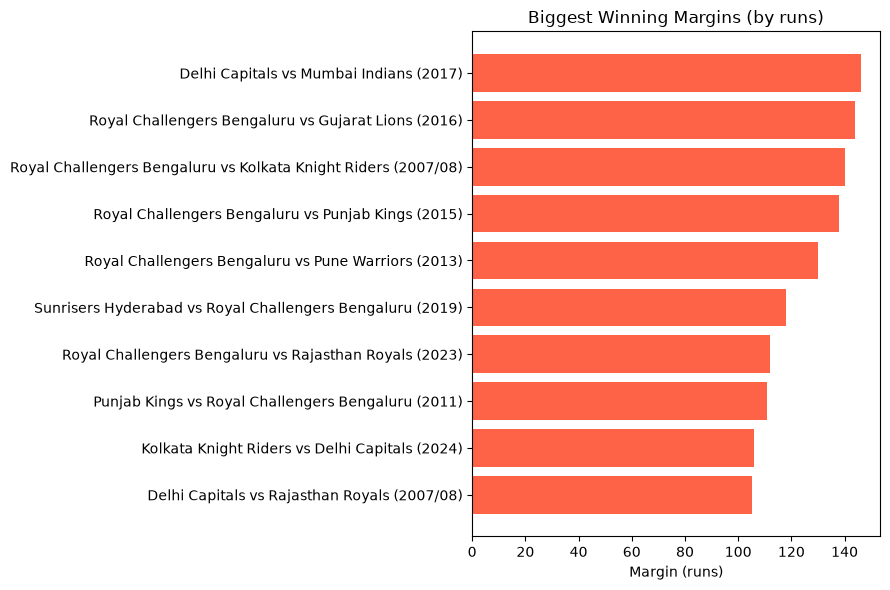

In [86]:
top_margins = biggest_run_wins.head(10).copy()
top_margins['matchup_label'] = (
    top_margins['team1'] + ' vs ' + top_margins['team2'] +
    ' (' + top_margins['season'].astype(str) + ')'
)

plt.figure(figsize=(9, 6))
plt.barh(top_margins['matchup_label'], top_margins['result_margin'], color='tomato')
plt.title('Biggest Winning Margins (by runs)')
plt.xlabel('Margin (runs)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** The biggest run-margin win in IPL history is Mumbai Indians beating Delhi Capitals by 146 runs in 2017, followed by Royal Challengers Bengaluru's 144-run win over Gujarat Lions (2016) and Kolkata Knight Riders' 140-run win over Royal Challengers Bengaluru (2007/08). These blowouts are spread across different seasons and teams rather than concentrated in one era.

### How do the most-played rivalries stack up head-to-head?

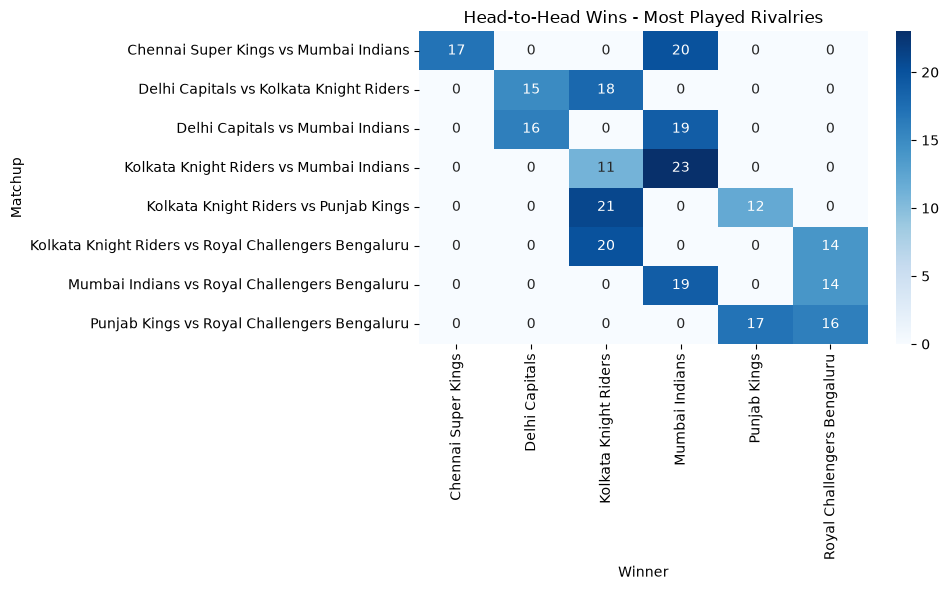

In [87]:
matchup_totals = head_to_head.groupby('matchup')['wins'].sum().sort_values(ascending=False)
top_rivalries = matchup_totals.head(8).index

h2h_pivot = (
    head_to_head[head_to_head['matchup'].isin(top_rivalries)]
    .pivot(index='matchup', columns='winner', values='wins')
    .fillna(0)
)

plt.figure(figsize=(10, 6))
sns.heatmap(h2h_pivot, annot=True, fmt='g', cmap='Blues')
plt.title('Head-to-Head Wins - Most Played Rivalries')
plt.xlabel('Winner')
plt.ylabel('Matchup')
plt.tight_layout()
plt.show()

**Insight:** Chennai Super Kings vs Mumbai Indians is the most-played rivalry (37 matches) — and it's close, with Mumbai Indians narrowly ahead 20 wins to 17. Other frequently played pairings like Kolkata Knight Riders vs Royal Challengers Bengaluru (14-14 split within their top-8 matchups shown) are similarly balanced, showing most long-running rivalries even out over time rather than being one-sided.

## Key Takeaways

- Winning the toss has almost no bearing on winning the match (50.83% vs 49.17% — essentially a coin flip).
- Fielding first after winning the toss wins more often (53.86%) than batting first (45.38%).
- Gujarat Titans (62.2%) and Chennai Super Kings (57.98%) have the best all-time win percentages; Pune Warriors (26.09%) the worst.
- No team wins consistently every season — 8 different franchises have topped a season's win count across 17 seasons.
- V Kohli (8,014 runs) leads all-time run scoring, but the highest strike rates (J Fraser-McGurk, 220.0) belong to entirely different, more explosive players.
- YS Chahal (205 wickets) leads wicket-taking, while A Kumble (6.58 economy) is the most economical — again, largely different skill sets and players.
- Scoring averages vary meaningfully by venue (200 runs at Visakhapatnam vs ~128 runs at Newlands), pointing to real pitch/ground effects.
- The biggest blowout win is Mumbai Indians' 146-run win over Delhi Capitals (2017); big margins are scattered across seasons, not concentrated in one era.
- Chennai Super Kings vs Mumbai Indians is the most-played rivalry (37 matches) and is nearly even (20-17 in MI's favor).